# Gráficos de tercer orden alfa beta

In [2]:
#alfa=0.03 , b=1
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# Bloques auxiliares
def E(b):
    return -7 + 288*b

def A(b):
    return 49 + 108*b*(-21 + np.sqrt(21)*np.sqrt(E(b)))

def D(b):
    return 93312*b**2 + 7*np.sqrt(21)*np.sqrt(E(b)) - \
           324*b*(7 + np.sqrt(21)*np.sqrt(E(b)))

def F(b):
    return -7*(7**(1/3)) + 216*(7**(1/3))*b + A(b)**(2/3)

def C(b, mu2):
    return -(972*(7**(2/3))*( -7 + 288*b)*A(b)**(4/3)*b*mu2)/(D(b)*F(b))

# Parte tipo Cardano
def Q(r2, b, mu2):
    return -7*(-7 + 324*b)*r2**4 + C(b, mu2)

def R(r2, b, mu2):
    term1 = -18*(b**2)*r2**8
    
    term2 = (7**(2/3)*(-7 + 324*b)*A(b)**(4/3)*b*r2**4*mu2)/(-D(b)*F(b))
    
    term3 = (486*(7**(1/3))*(b**2)*(-7 + 288*b)**2 * A(b)**(8/3)*mu2**2) / (D(b)**2 * F(b)**2)
    
    inside = (7 - 288*b)*(term1 + term2 - term3)
    
    return 18*np.sqrt(42)*np.sqrt(inside)

def Cardano(r2, b, mu2):
    return (Q(r2, b, mu2) + R(r2, b, mu2))**(1/3)

# Función final
def f(r2, b, mu2):
    return (1 + r2**2 +
            ((7 - 216*b)*r2**(10/3)) / (7**(1/3) * Cardano(r2, b, mu2)) +
            (r2**(2/3) / (7**(2/3))) * Cardano(r2, b, mu2))

C:\Users\DanielManuelPechoVeg\AppData\Local\Temp\ipykernel_11132\2181457677.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("turbo")   # O "viridis", "plasma", "rainbow"


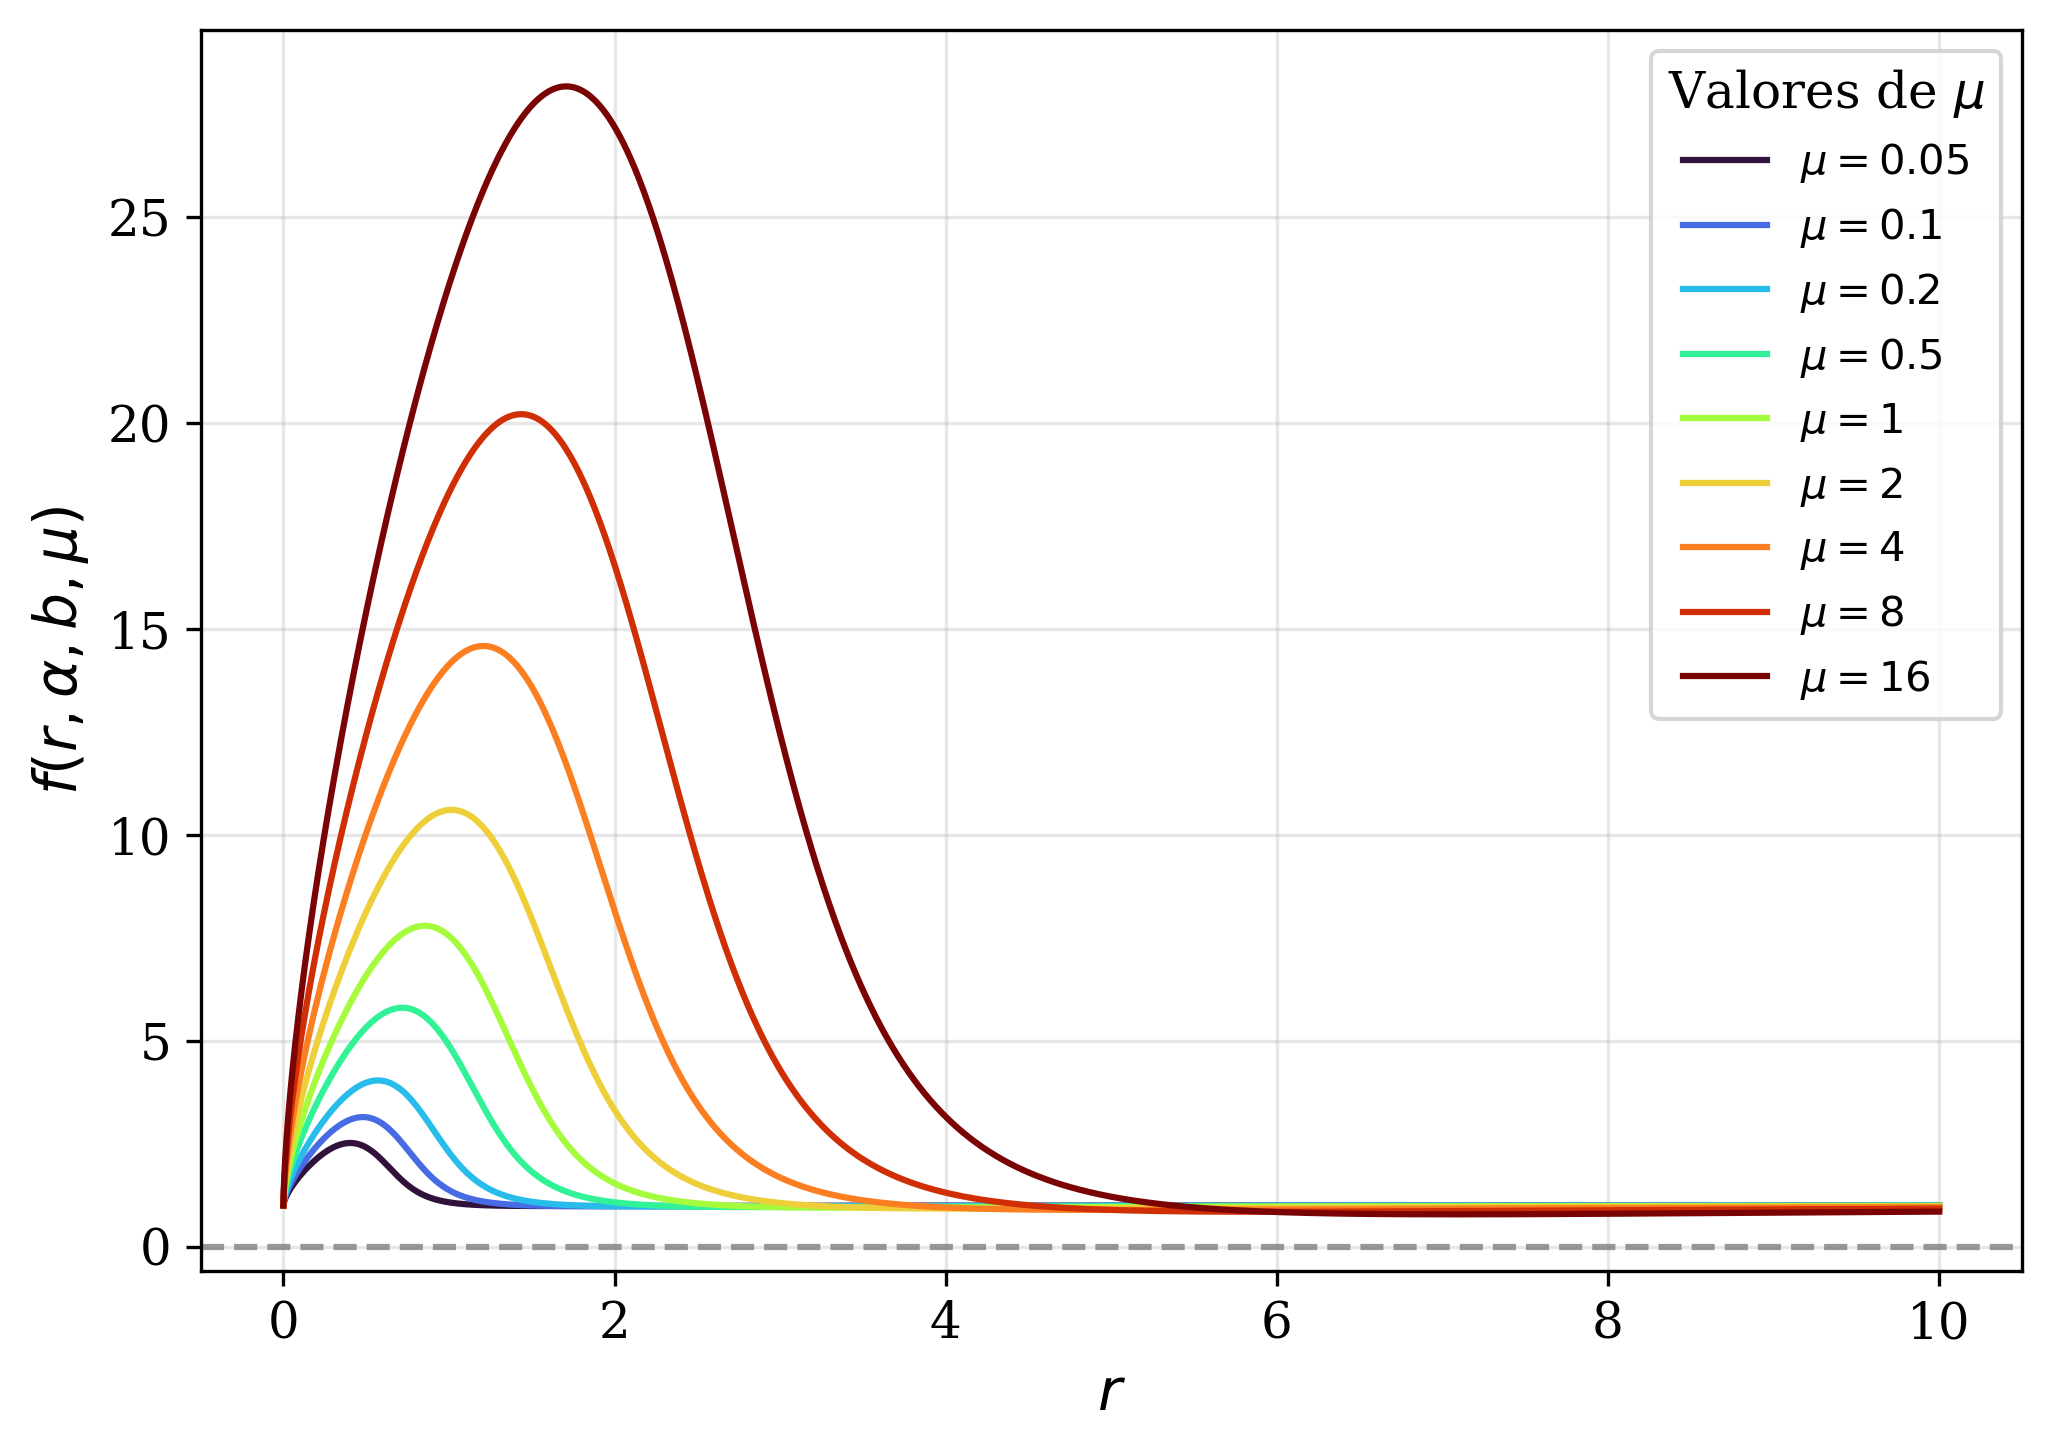

In [3]:
r_vals = np.linspace(0, 10, 10000)
mu_list = [0.05, 0.1, 0.2, 0.5, 1, 2, 4, 8,16]
b_list = [0.07, 0.1, 0.2, 0.5, 1, 2, 4, 8,16]

#mu_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07,0.08,0.09,0.1]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "figure.dpi": 300,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 10,
    "lines.linewidth": 1.5
})

# Colormap profesional tipo arcoiris
cmap = get_cmap("turbo")   # O "viridis", "plasma", "rainbow"

# Graficar
plt.figure(figsize=(7,5))

for i, mu in enumerate(mu_list):
    color = cmap(i / (len(mu_list) - 1))
    plt.plot(r_vals, f(r_vals,1, mu), color=color, label=f"$\\mu = {mu}$")

plt.xlabel("$r$")
plt.ylabel("$f(r,\\alpha,b,\\mu)$")
#plt.title("$f(r,\\alpha,b,\\mu)$ para varios valores de $\\mu$")
plt.grid(True, alpha=0.3)
plt.legend(title="Valores de $\\mu$", frameon=True)
plt.tight_layout()
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    alpha=0.8,
    label="$f(r)=0$"
)
plt.savefig("grafico_f alfabeta Zprim variando mu.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\DanielManuelPechoVeg\AppData\Local\Temp\ipykernel_17176\4163215275.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("turbo")   # O "viridis", "plasma", "rainbow"


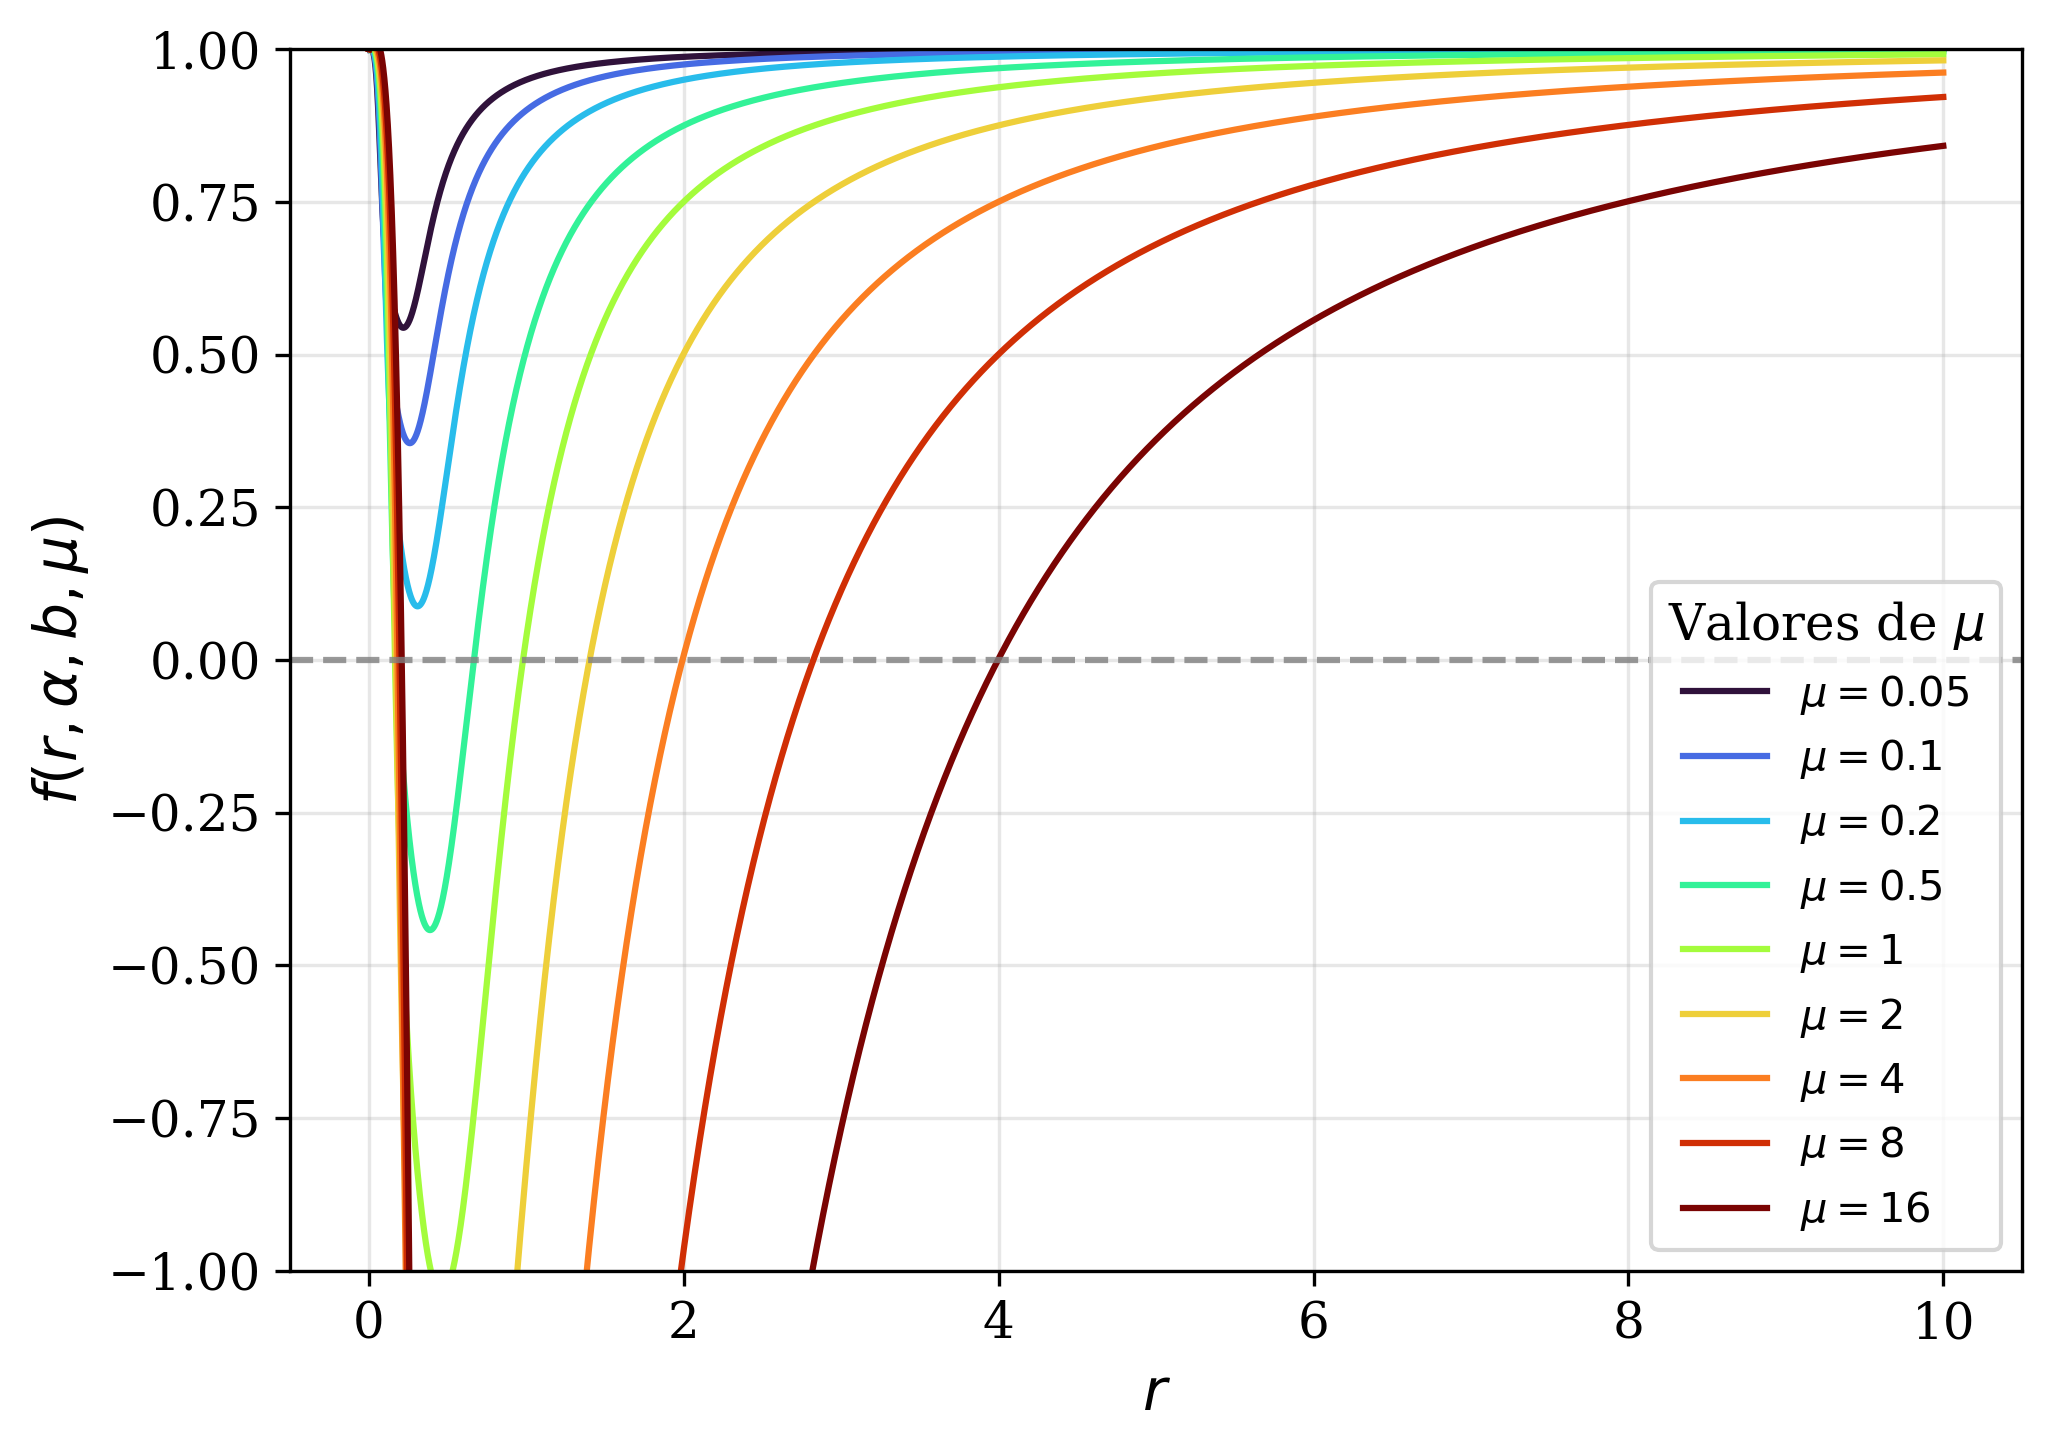

In [7]:
r_vals = np.linspace(0, 10, 10000)
mu_list = [0.05, 0.1, 0.2, 0.5, 1, 2, 4, 8,16]
b_list = [0.07, 0.1, 0.2, 0.5, 1, 2, 4, 8,16]

#mu_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07,0.08,0.09,0.1]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "figure.dpi": 300,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 10,
    "lines.linewidth": 1.5
})

# Colormap profesional tipo arcoiris
cmap = get_cmap("turbo")   # O "viridis", "plasma", "rainbow"

# Graficar
plt.figure(figsize=(7,5))

for i, mu in enumerate(mu_list):
    color = cmap(i / (len(mu_list) - 1))
    plt.plot(r_vals, f(r_vals, mu), color=color, label=f"$\\mu = {mu}$")

plt.xlabel("$r$")
plt.ylabel("$f(r,\\alpha,b,\\mu)$")
#plt.title("$f(r,\\alpha,b,\\mu)$ para varios valores de $\\mu$")
plt.grid(True, alpha=0.3)
plt.ylim(-1, 1)
plt.legend(title="Valores de $\\mu$", frameon=True)
plt.tight_layout()
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    alpha=0.8,
    label="$f(r)=0$"
)

plt.savefig("grafico_f alfabeta Zprim variando mu zoom.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\DanielManuelPechoVeg\AppData\Local\Temp\ipykernel_17176\3062831366.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("turbo")   # O "viridis", "plasma", "rainbow"
C:\Users\DanielManuelPechoVeg\AppData\Local\Temp\ipykernel_17176\3793453575.py:69: RuntimeWarning: divide by zero encountered in divide
  + (72*(7 - 216*b)*b*alpha**2*r**4)/(7**(4/3)*np.cbrt(C))
C:\Users\DanielManuelPechoVeg\AppData\Local\Temp\ipykernel_17176\3793453575.py:69: RuntimeWarning: invalid value encountered in divide
  + (72*(7 - 216*b)*b*alpha**2*r**4)/(7**(4/3)*np.cbrt(C))


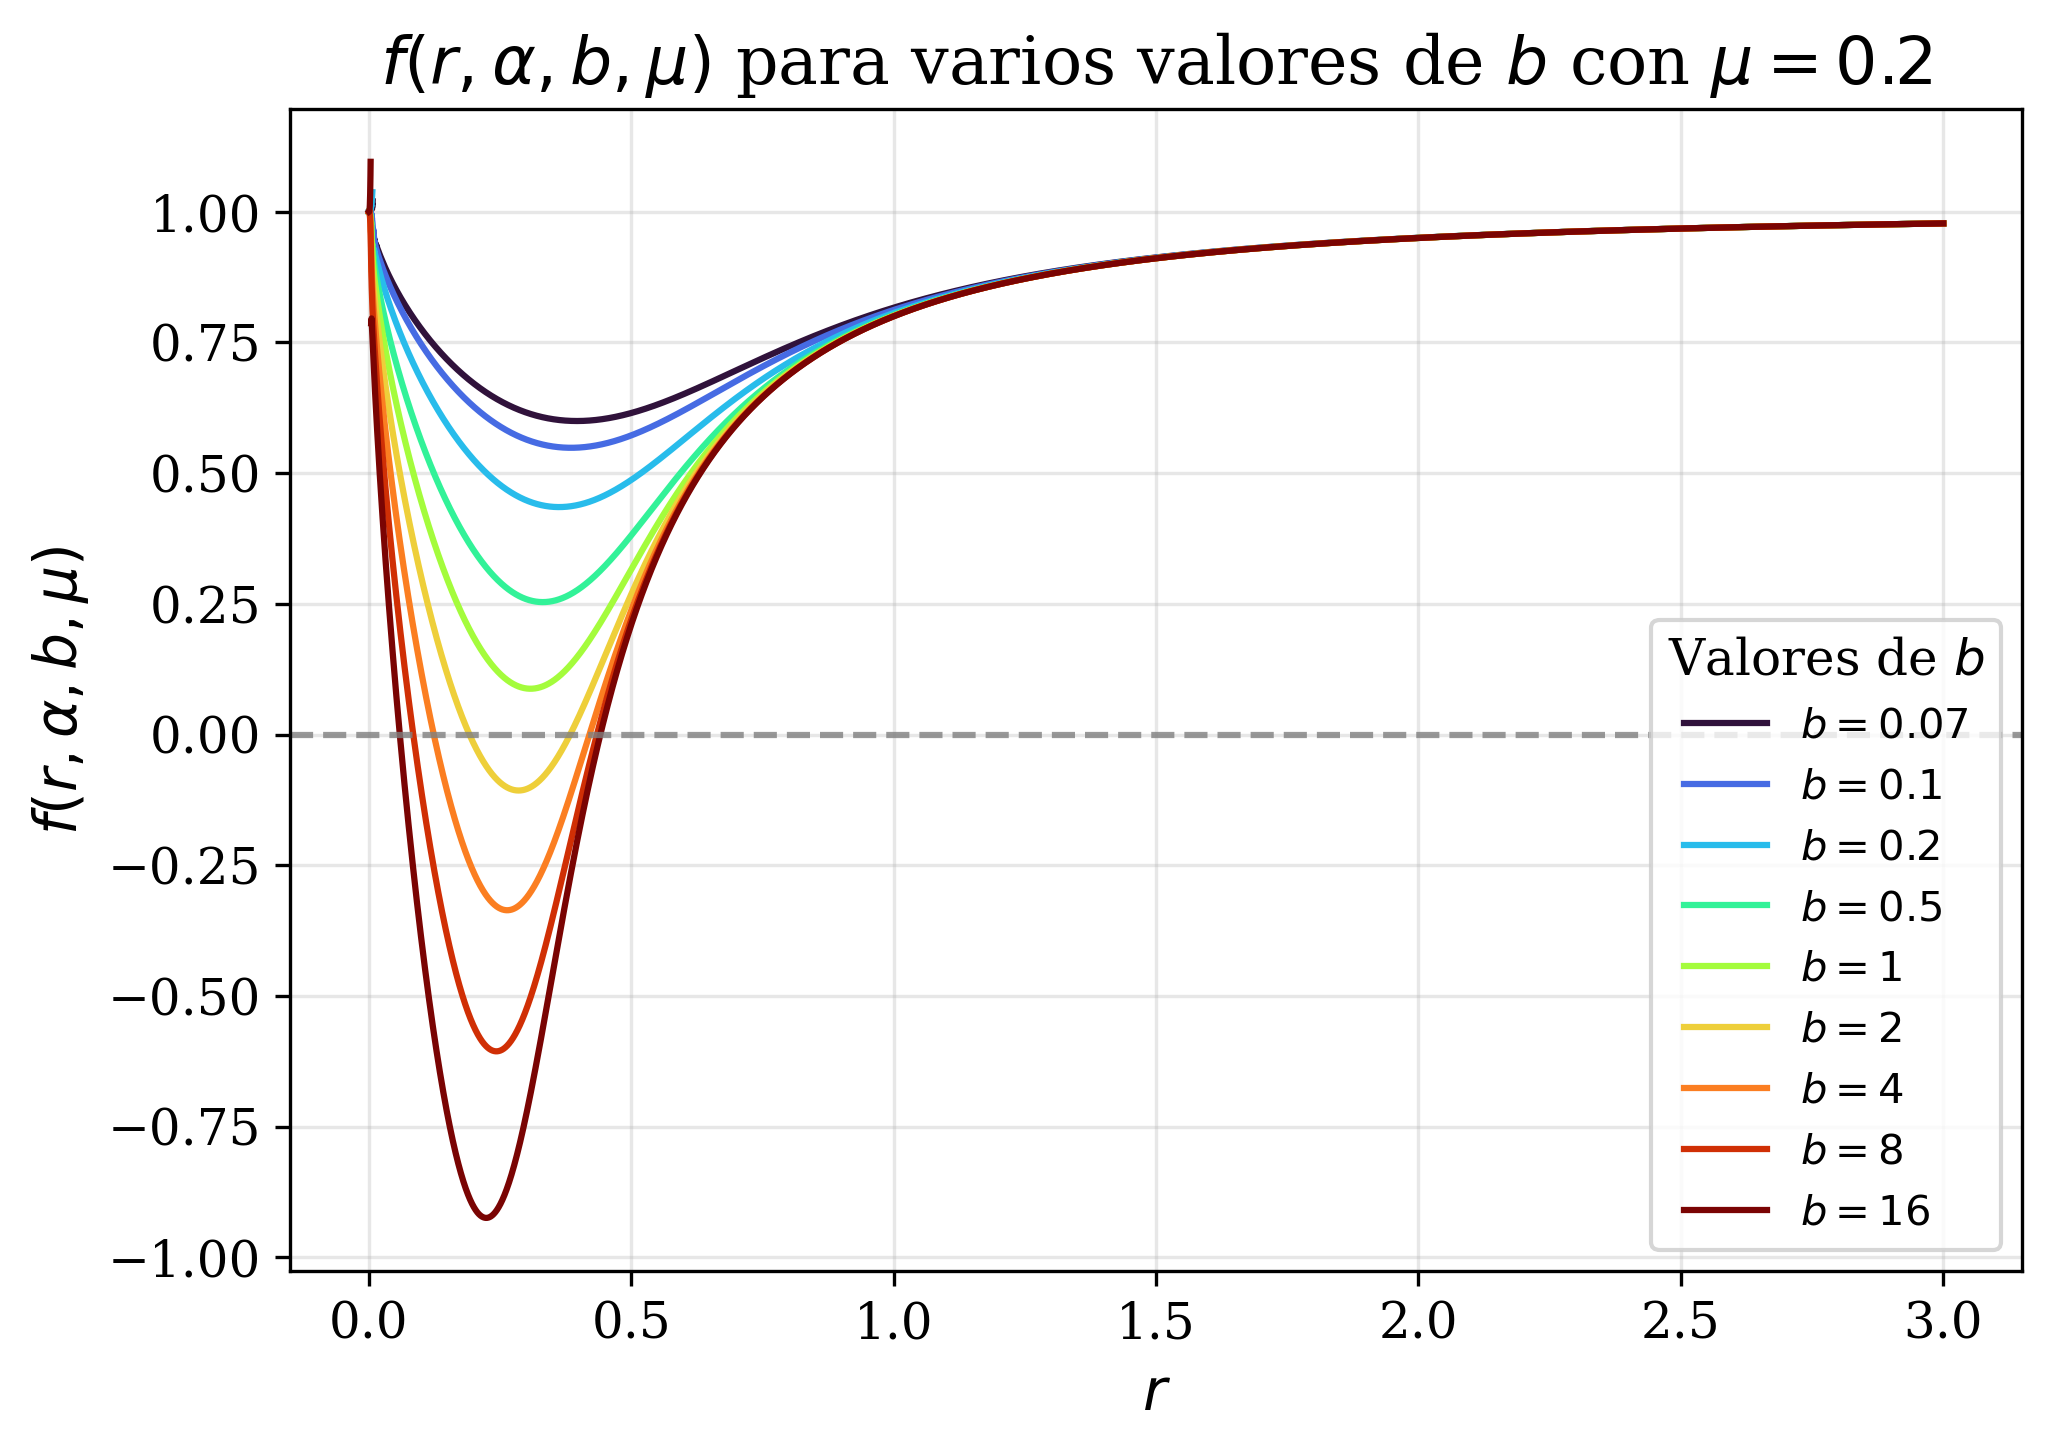

In [24]:
r_vals = np.linspace(0, 3, 10000)
mu_list = [0.05, 0.1, 0.2, 0.5, 1, 2, 4, 8,16]
b_list = [0.07, 0.1, 0.2, 0.5, 1, 2, 4, 8,16]

#mu_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07,0.08,0.09,0.1]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "figure.dpi": 300,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 10,
    "lines.linewidth": 1.5
})

# Colormap profesional tipo arcoiris
cmap = get_cmap("turbo")   # O "viridis", "plasma", "rainbow"

# Graficar
plt.figure(figsize=(7,5))

for i, b in enumerate(b_list):
    color = cmap(i / (len(b_list) - 1))
    plt.plot(r_vals, fcompleta(r_vals, b, 0.03, 0.2),
             color=color, label=f"$b = {b}$")

plt.xlabel("$r$")
plt.ylabel("$f(r,\\alpha,b,\\mu)$")
plt.title("$f(r,\\alpha,b,\\mu)$ para varios valores de $b$ con $\\mu=0.2$")
plt.grid(True, alpha=0.3)
plt.legend(title="Valores de $b$", frameon=True)
plt.tight_layout()
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    alpha=0.8,
    label="$f(r)=0$"
)

plt.savefig("grafico_f alfabeta Zprim variando b.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\Danito\AppData\Local\Temp\ipykernel_4124\2912438113.py:10: RuntimeWarning: invalid value encountered in divide
  return 1 + r**2 - (0.467486*(r**4))/C + 30.8642*C


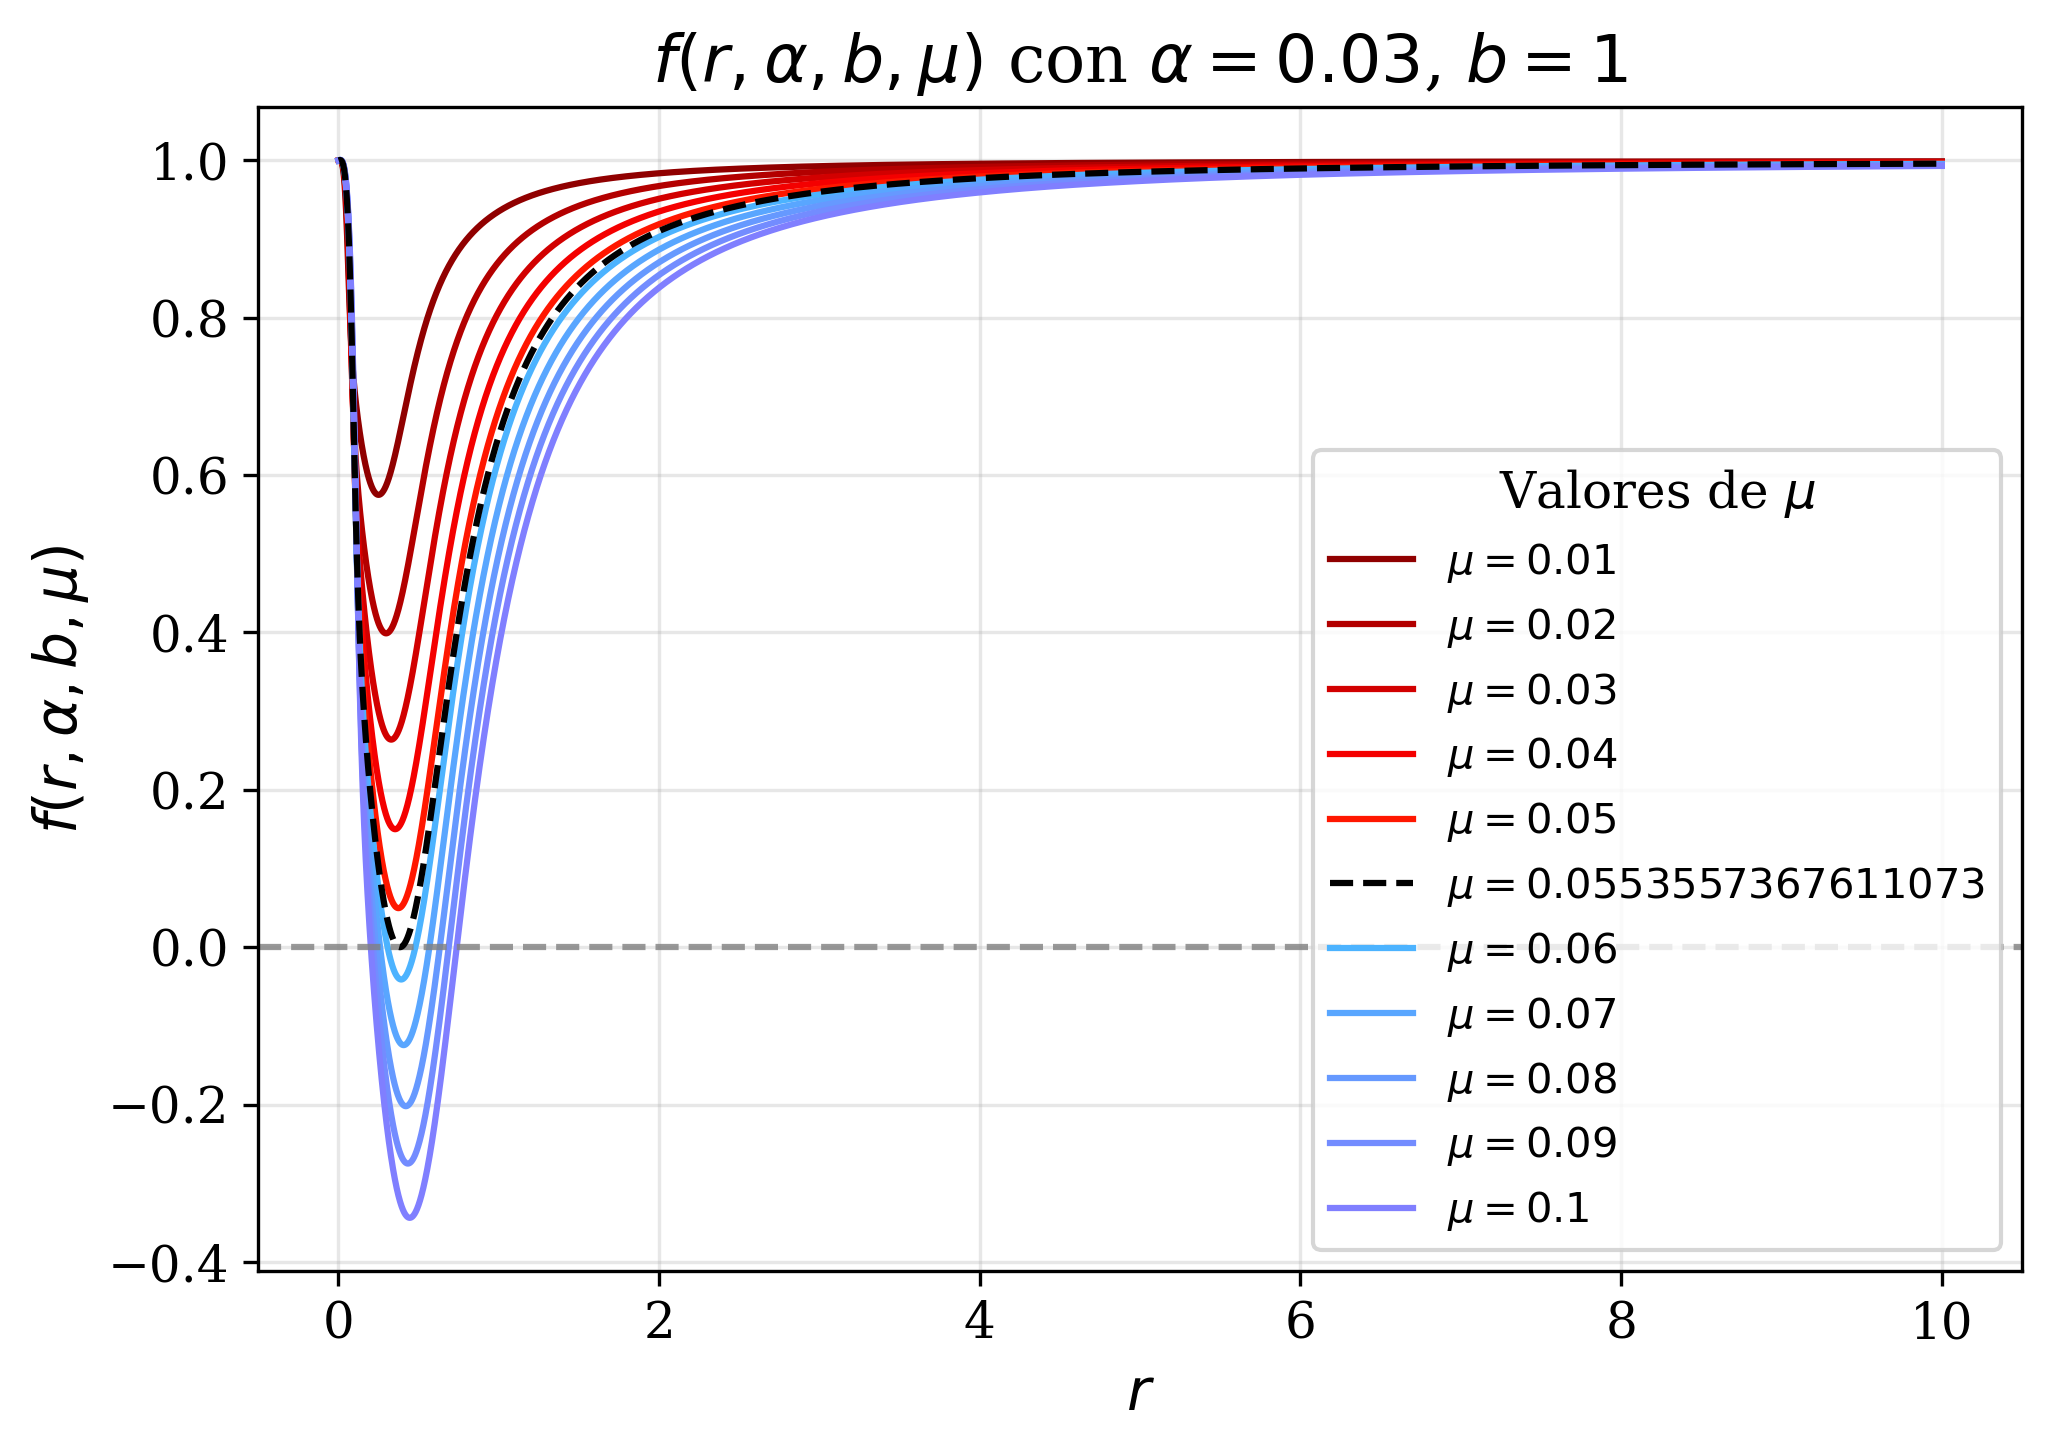

In [20]:
r_vals = np.linspace(0, 10, 10000)
mu_crit = 0.0553557367611073
mu_list = [0.01, 0.02, 0.03, 0.04, 0.05,mu_crit,0.06,0.07,0.08,0.09,0.1]

plt.figure(figsize=(7,5))

mu_low  = [mu for mu in mu_list if mu < mu_crit]
mu_high = [mu for mu in mu_list if mu > mu_crit]

norm_low  = plt.Normalize(min(mu_low), max(mu_low)) if mu_low else None
norm_high = plt.Normalize(min(mu_high), max(mu_high)) if mu_high else None

# Rangos restringidos del colormap
hot_min, hot_max   = 0.2, 0.4   # solo rojos
cool_min, cool_max = 0.3, 0.5   # solo azules

for mu in mu_list:
    if mu < mu_crit:
        t = norm_low(mu)
        color = plt.cm.hot(hot_min + t * (hot_max - hot_min))
        plt.plot(
            r_vals, f(r_vals, mu),
            color=color,
            label=rf"$\mu = {mu}$"
        )

    elif mu > mu_crit:
        t = norm_high(mu)
        color = plt.cm.cool(cool_min + t * (cool_max - cool_min))
        plt.plot(
            r_vals, f(r_vals, mu),
            color=color,
            label=rf"$\mu = {mu}$"
        )

    else:
        plt.plot(
            r_vals, f(r_vals, mu),
            color="black",
            linestyle="--",
            linewidth=1.5,
            zorder=10,
            label=rf"$\mu = {mu}$"
        )

plt.xlabel(r"$r$")
plt.ylabel(r"$f(r,\alpha,b,\mu)$")
plt.title(r"$f(r,\alpha,b,\mu)$ con $\alpha=0.03$, $b=1$")
plt.grid(True, alpha=0.3)
plt.legend(title=r"Valores de $\mu$", frameon=True)
plt.tight_layout()

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    alpha=0.8,
    label="$f(r)=0$"
)
plt.savefig("Extremal_BlackHole.png", dpi=300, bbox_inches="tight")
plt.show()